In [23]:
# Conda dependencies are listed under environment.yml
import os
import sys
import copy
from datetime import datetime, timedelta
import getpass
import logging
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import num2date, date2num
import numpy as np
import pdb
import pickle
import requests
import scipy.io
from scipy import stats
import scipy
import warnings
from sunpy.time import parse_time
import sklearn
import pandas as pd
import matplotlib.dates as mdates
import astropy.units as u
from scipy.optimize import curve_fit, least_squares, minimize
import plotly.express as px
import plotly.graph_objects as go
from datetime import timezone

import time
import numba
from numba import jit
from astropy.time import Time, TimeDelta
from sunpy.coordinates import HeliographicStonyhurst, HeliocentricEarthEcliptic
import astrospice
#from heliocats import data as hd
from functions.data import SatData
from functions.data import PositionData
import urllib
import multiprocess as mp
#import functions_sta as fs

import seaborn as sns
from sklearn.metrics import mean_squared_error
#from heliocats import plot as hp
#import heliocats.data as hd

#import heliosat
#import predstorm as ps
from functions import data as data_sat
from functions import predict as pred
#from predstorm.config.conscnts import AU, dist_to_L1
#from predstorm.predict import dst_loss_function

warnings.filterwarnings('ignore') # some numpy mean-of-empty-slice runtime warnings


sns.set_style('whitegrid', {'xtick.bottom': False, 'grid.color': 'gainsboro'})
sns.set_context('paper')


c0 = "xkcd:black"
c1 = "xkcd:magenta"
c2 = "xkcd:orange"
c3 = "xkcd:azure"
c4 = "xkcd:green"

data_path = 'data/'

In [24]:
def interp_nans(sc_in, single=False):
    sc = copy.deepcopy(sc_in)
    
    n = len(sc)

    # Use index positions as the x-axis (since time steps are regular)
    x = np.arange(n)
    
    if single:
        mask = ~np.isnan(sc)
        
        if np.sum(mask) >= 2:  # Need at least 2 points to interpolate
            # Interpolate over valid points
            sc = np.interp(x, x[mask], sc[mask])
        else:
            print(f"Skipping '{key}': not enough valid data to interpolate.")
            
    else:
        keys_to_interp = [name for name in sc.dtype.names if name != 'time']

        for key in keys_to_interp:
            y = sc[key]

            if y.dtype.kind in 'f':  # Only interpolate float fields
                mask = ~np.isnan(y)

                if np.sum(mask) >= 2:  # Need at least 2 points to interpolate
                    # Interpolate over valid points
                    sc[key] = np.interp(x, x[mask], y[mask])
                else:
                    print(f"Skipping '{key}': not enough valid data to interpolate.")

                
    return sc

    
def interp_to_time(sc_in, time_shift_seconds, res=1):

        
    #define time grid here so that it is the same for all.
    #use more than just sigma uncertainty but rather all ensembles for binned data.
    #and then use the same ensemble size for SYM-H prediction and calculate error as for INGRID event.
    #ask Chris if this strategy is legit.

    sc = copy.deepcopy(sc_in)
    sc.time = [sc_in.time[i]+timedelta(seconds=time_shift_seconds[i].astype(float)) for i in range(len(sc_in.time))]#+np.array(random_time[:,j], dtype='timedelta64[s]'


    t_start=datetime(2022,11,11)#sc.time[0].astype(datetime)
    t_end=datetime(2024,6,5)#sc.time[-1].astype(datetime)

    t1=sc.time

    format_str = '%Y-%m-%d %H:%M'  
    t0 = datetime.strptime(datetime.strftime(t_start, format_str), format_str) #+timedelta(minutes=1)

    time_all = [ t0 + timedelta(minutes=res*n) for n in range(int ((t_end - t_start).days*(60./res)*24)+1)]
    time_mat=mdates.date2num(time_all) 

    sc_rec=np.zeros(np.size(time_all),dtype=[('time',object),('bx', float),('by', float),\
            ('bz', float),('bt', float),('r', float),('lat', float),('lon', float),\
            ('x', float),('y', float),('z', float),('vx', float),\
            ('vy', float),('vz', float),('vt', float),('tp', float),('np', float), ('symh', float) ] ) 

    sc_rec=sc_rec.view(np.recarray)  

    time_m_num=mdates.date2num(t1) #make date number

    sc_rec.time=time_all


    sc_rec.np=np.interp(time_mat, time_m_num, sc.np)
    sc_rec.tp=np.interp(time_mat, time_m_num, sc.tp) 
    sc_rec.vt=np.interp(time_mat, time_m_num, sc.vt)

    sc_rec.bx=np.interp(time_mat, time_m_num, sc.bx)
    sc_rec.by=np.interp(time_mat, time_m_num, sc.by)
    sc_rec.bz=np.interp(time_mat, time_m_num, sc.bz)
    sc_rec.bt=np.interp(time_mat, time_m_num, sc.bt)

    sc_rec.x=np.interp(time_mat, time_m_num, sc.x)
    sc_rec.y=np.interp(time_mat, time_m_num, sc.y)
    sc_rec.z=np.interp(time_mat, time_m_num, sc.z)

    sc_rec.symh=np.zeros(len(time_all))

    sc_rec.r=np.interp(time_mat, time_m_num, sc.r)
    sc_rec.lon=np.interp(time_mat, time_m_num, sc.lon)
    sc_rec.lat=np.interp(time_mat, time_m_num, sc.lat)

    #sc_rec_interp = interp_nans(sc_rec)

    return sc_rec

In [25]:

def despike_density(den_in):


    #set all nan to 0 in the v gradient array
    den1=copy.deepcopy( abs( np.gradient(den_in)   ))
    den = copy.deepcopy(den_in)
    den[den>100]=np.nan
    den1nan_ind=np.where(np.isnan(den1)==True)[0]
    den1[den1nan_ind]=0
 
    peaks, properties = scipy.signal.find_peaks(den1, prominence=10, width=(1, 50))
    den[np.where(den1>10)]=np.nan
    den1[np.where(den1>10)]=np.nan

    for i in np.arange(len(peaks)):
         width=int(np.ceil(properties['widths'])[i])
         #print(width)   
         den[peaks[i]-width:peaks[i]+width]=np.nan

    return den


## Data reading

In [51]:
l1_input = pickle.load(open(data_path+'noaa_20221111_20240604_B_GSM_Coords_GSE.p', 'rb'))
sc_beacon = pickle.load(open(data_path+'sta_beacon_20221111_20240604_B_GSM_Coords_GSE_new.p', 'rb'))
sc_science = pickle.load(open(data_path+'sta_science_20221111_20240604_B_GSM_Coords_GSE_new.p', 'rb'))

#data1 = pickle.load(open(data_path+'sta_symh_final_beacon_plasma_445.p', 'rb'))
#[delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc_455, delta_t_mean_sc_455, delta_t_mean_sc1_455, delta_t_std_sc_455] = pickle.load(open(data_path+'mean_time_shift_and_sigma_beacon_plasma.p', 'rb'))
omni_input = pickle.load(open(data_path+'omni_20221111_20240604.p', 'rb'))

beacon = True
use_plasma = True

if beacon:
    sc_input = sc_beacon
    if use_plasma:
        sc_input.np = sc_science.np
        sc_input.vt = sc_science.vt

else:
    sc_input = sc_science

#wind_input_heeq = pickle.load(open(data_path+'noaa_20221111_20240604_GSM.p', 'rb'))
#sc_input_heeq =  pickle.load(open(data_path+'sta_beacon_20221101_20240601_gsm.p', 'rb'))
sc_input_heeq = pickle.load(open(data_path+'sta_science_HEEQ_20221111_20240604.p', 'rb'))
earth_pos = pickle.load(open(data_path+'earth_pos_HEEQ_20221111_20240604.p', 'rb'))

delta_r_earth = earth_pos.r-sc_input_heeq.r

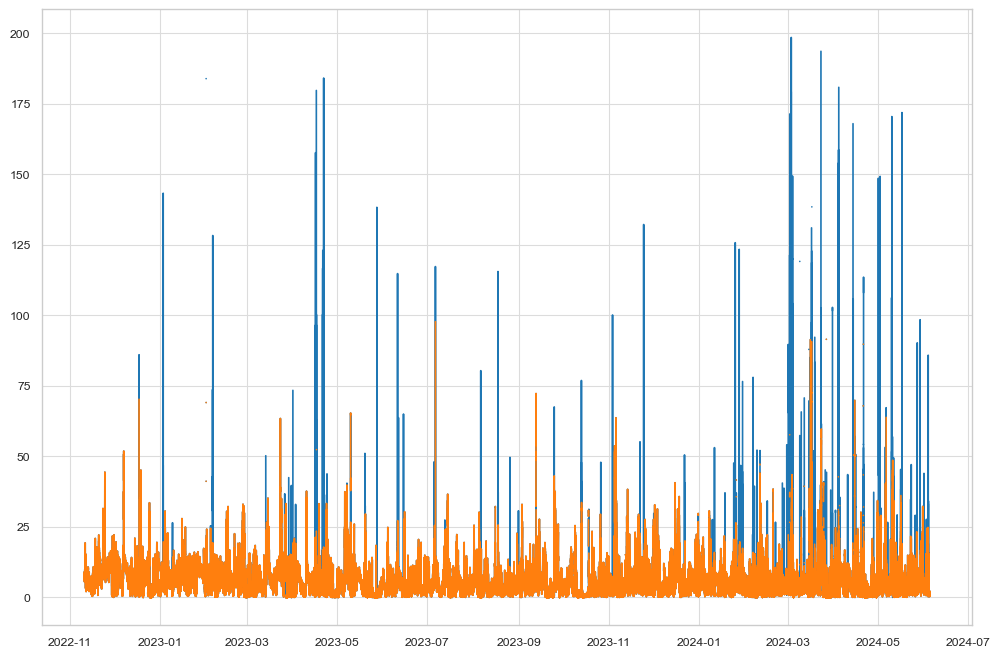

In [27]:
l1_input_np = despike_density(l1_input.np)

plt.figure(figsize=(12,8))
plt.plot(l1_input.time, l1_input.np)
plt.plot(l1_input.time, l1_input_np)

l1_input.np = l1_input_np

### Calculate statistics for Section 3 in paper
1. Differences in arrival time
2. Differences in time of min(vBz)
3. Relative change of Btot, density, and speed

In [28]:
import_diff_arrival = True

if import_diff_arrival:

    times = pd.read_csv(data_path+'CME_events_times_new.csv', header=0, delimiter=';')
    times.sta_start = pd.to_datetime(times.sta_start, format='%Y-%m-%dT%H:%MZ')
    times.sta_end = pd.to_datetime(times.sta_end, format='%Y-%m-%dT%H:%MZ')
    times.l1_start = pd.to_datetime(times.l1_start, format='%Y-%m-%dT%H:%MZ')
    times.l1_end = pd.to_datetime(times.l1_end, format='%Y-%m-%dT%H:%MZ')
    
    diff_arrival_hours = np.array([(i-j).total_seconds()/3600 for i,j in zip(times.l1_start, times.sta_start)])

    print('Number of identified CMEs:', len(times.l1_start))

Number of identified CMEs: 32


In [29]:
print('Difference in arrival time for 32 CME events:')

for i in range(len(diff_arrival_hours)):
    print('CME event ', str(i+1), diff_arrival_hours[i])

Difference in arrival time for 32 CME events:
CME event  1 9.05
CME event  2 -15.6
CME event  3 6.45
CME event  4 2.5166666666666666
CME event  5 9.75
CME event  6 -20.25
CME event  7 2.4833333333333334
CME event  8 3.0
CME event  9 4.7
CME event  10 6.8
CME event  11 5.75
CME event  12 3.0166666666666666
CME event  13 4.966666666666667
CME event  14 4.716666666666667
CME event  15 3.533333333333333
CME event  16 3.85
CME event  17 2.3
CME event  18 -0.35
CME event  19 4.45
CME event  20 1.9
CME event  21 2.7333333333333334
CME event  22 -1.2666666666666666
CME event  23 1.45
CME event  24 -1.2833333333333334
CME event  25 0.45
CME event  26 2.783333333333333
CME event  27 -1.8666666666666667
CME event  28 -0.26666666666666666
CME event  29 -4.616666666666666
CME event  30 22.05
CME event  31 1.8333333333333333
CME event  32 2.5833333333333335


In [57]:
diff_time_max_bv = []
diff_time_min_bz = []
diff_val_max_bv = []
diff_val_min_bz = []
mean_speed_events = []
mean_density_events = []
sc_time_max_bv = []
l1_time_max_bv = []

for i in range(len(times.sta_start)):
    
    if (i+1)==26:
        sc_input = sc_science
    else: sc_input=sc_input
    
    print('Processing: ', str(i+1))
    
    #cut data for faster use
    #sc_cut = sc_input[(sc_input.time>=t_start) & (sc_input.time<=t_end)]
    sc_cut_event = sc_input[(sc_input.time>=times.sta_start[i]) & (sc_input.time<=times.sta_end[i])]
    #l1_cut = l1_input[(l1_input.time>=t_start) & (l1_input.time<=t_end)]
    l1_cut_event = l1_input[(l1_input.time>=times.l1_start[i]) & (l1_input.time<=times.l1_end[i])]
    
    sc_max_bv_time = sc_cut_event.time[sc_cut_event.bz*sc_cut_event.vt==np.nanmin(sc_cut_event.bz*sc_cut_event.vt)]
    l1_max_bv_time = l1_cut_event.time[l1_cut_event.bz*l1_cut_event.vt==np.nanmin(l1_cut_event.bz*l1_cut_event.vt)]
    sc_max_bv_val = sc_cut_event.bz[sc_cut_event.time==sc_max_bv_time]#*sc_cut_event.vt[sc_cut_event.time==sc_max_bv_time]
    l1_max_bv_val = l1_cut_event.bz[l1_cut_event.time==l1_max_bv_time]#*l1_cut_event.vt[l1_cut_event.time==l1_max_bv_time]
    sc_max_bv_val_vt = sc_cut_event.vt[sc_cut_event.time==sc_max_bv_time]
    l1_max_bv_val_vt = l1_cut_event.vt[l1_cut_event.time==l1_max_bv_time]
    sc_min_bz_time = sc_cut_event.time[sc_cut_event.bz==np.nanmin(sc_cut_event.bz)]
    l1_min_bz_time = l1_cut_event.time[l1_cut_event.bz==np.nanmin(l1_cut_event.bz)]
    
    diff_bv_time = np.round((l1_max_bv_time-sc_max_bv_time)[0].total_seconds()/3600.,1)
    diff_bv_val = (l1_max_bv_val-sc_max_bv_val)
    diff_bv_val_vt = (l1_max_bv_val_vt-sc_max_bv_val_vt)
    diff_bz = np.round((l1_min_bz_time-sc_min_bz_time)[0].total_seconds()/3600.,1)
    mean_speed_sc = np.nanmean(sc_cut_event.vt)
    mean_speed_l1 = np.nanmean(l1_cut_event.vt)
    mean_density_sc = np.nanmean(sc_cut_event.np)
    mean_density_l1 = np.nanmean(l1_cut_event.np)
    
    print(sc_max_bv_time[0])
    print(diff_bv_val[0]*diff_bv_val_vt[0])
    print(' ')
    
    diff_time_max_bv.append(diff_bv_time)
    diff_time_min_bz.append(diff_bz)
    diff_val_max_bv.append(diff_bv_val[0])
    sc_time_max_bv.append(sc_max_bv_time[0])
    l1_time_max_bv.append(l1_max_bv_time[0])

    mean_speed_events.append([mean_speed_sc, mean_speed_l1])
    mean_speed_events.append([mean_density_sc, mean_density_l1])
    
#print(diff_time_min_bz)


Processing:  1
2022-12-18 15:21:00
-733.3929365623246
 
Processing:  2
2023-01-04 23:27:00
192.84303162925445
 
Processing:  3
2023-01-17 15:35:00
-1.1518739801830147
 
Processing:  4
2023-03-15 05:47:00
265.7459322758723
 
Processing:  5
2023-03-23 14:18:00
-40.67298680303469
 
Processing:  6
2023-04-20 05:24:00
-370.10473372488923
 
Processing:  7
2023-04-23 23:42:00
-104.37719508525646
 
Processing:  8
2023-05-10 09:17:00
295.57277408544854
 
Processing:  9
2023-05-12 10:39:00
643.0472543321528
 
Processing:  10
2023-07-14 10:37:00
-11.17748347345565
 
Processing:  11
2023-07-16 13:21:00
736.6310618007548
 
Processing:  12
2023-07-26 00:53:00
14.3697083750592
 
Processing:  13
2023-08-02 01:32:00
-16.463260315612228
 
Processing:  14
2023-08-05 02:19:00
-131.52654760230342
 
Processing:  15
2023-09-12 10:01:00
-3.86084656987462
 
Processing:  16
2023-09-18 14:34:00
107.24333207580699
 
Processing:  17
2023-09-25 00:47:00
43.57717160384972
 
Processing:  18
2023-10-20 22:53:00
13.184

In [59]:
print('Difference in timing of min(vBz) [h]:')

for i in range(len(times.l1_start)):
    print('CME event', str(i+1), ':' , times.l1_start[i], diff_time_max_bv[i])

Difference in timing of min(vBz) [h]:
CME event 1 : 2022-12-18 19:51:00 13.7
CME event 2 : 2023-01-03 20:58:00 -17.9
CME event 3 : 2023-01-17 21:03:00 7.4
CME event 4 : 2023-03-15 03:47:00 -1.2
CME event 5 : 2023-03-23 07:31:00 5.3
CME event 6 : 2023-04-19 08:15:00 -19.0
CME event 7 : 2023-04-23 16:58:00 1.7
CME event 8 : 2023-05-09 22:06:00 -9.8
CME event 9 : 2023-05-12 05:48:00 33.2
CME event 10 : 2023-07-14 15:24:00 7.1
CME event 11 : 2023-07-16 18:35:00 8.1
CME event 12 : 2023-07-25 21:52:00 3.1
CME event 13 : 2023-08-01 11:06:00 11.3
CME event 14 : 2023-08-04 06:52:00 0.2
CME event 15 : 2023-09-12 10:24:00 4.4
CME event 16 : 2023-09-18 12:55:00 2.2
CME event 17 : 2023-09-24 19:53:00 -4.1
CME event 18 : 2023-10-20 08:04:00 4.8
CME event 19 : 2023-11-05 08:06:00 1.8
CME event 20 : 2023-11-12 05:30:00 -37.2
CME event 21 : 2023-11-30 23:34:00 -0.7
CME event 22 : 2023-12-15 10:56:00 -2.6
CME event 23 : 2023-12-29 11:37:00 1.8
CME event 24 : 2024-01-03 14:20:00 0.8
CME event 25 : 2024-0

In [55]:
btot_sta_list = []
btot_l1_list = []
bx_sta_list = []
bx_l1_list = []
by_sta_list = []
by_l1_list = []
bz_sta_list = []
bz_l1_list = []
vel_sta_list = []
vel_l1_list = []
den_sta_list = []
den_l1_list = []

for i in range(len(times.sta_start)):
    
    if (i+1)==26:
        sc_input = sc_science
    else: sc_input=sc_input
    
    btot_sta = sc_input.bt[(sc_input.time >= times.sta_start[i]) & (sc_input.time <= times.sta_end[i])]
    btot_l1 = l1_input.bt[(l1_input.time >= times.l1_start[i]) & (l1_input.time <= times.l1_end[i])]
    btot_sta_list.append(np.nanmean(btot_sta))
    btot_l1_list.append(np.nanmean(btot_l1))
    
    bx_sta = sc_input.bx[(sc_input.time >= times.sta_start[i]) & (sc_input.time <= times.sta_end[i])]
    bx_l1 = l1_input.bx[(l1_input.time >= times.l1_start[i]) & (l1_input.time <= times.l1_end[i])]
    bx_sta_list.append(np.nanmean(bx_sta))
    bx_l1_list.append(np.nanmean(bx_l1))
    
    by_sta = sc_input.by[(sc_input.time >= times.sta_start[i]) & (sc_input.time <= times.sta_end[i])]
    by_l1 = l1_input.by[(l1_input.time >= times.l1_start[i]) & (l1_input.time <= times.l1_end[i])]
    by_sta_list.append(np.nanmean(by_sta))
    by_l1_list.append(np.nanmean(by_l1))
    
    bz_sta = sc_input.bz[(sc_input.time >= times.sta_start[i]) & (sc_input.time <= times.sta_end[i])]
    bz_l1 = l1_input.bz[(l1_input.time >= times.l1_start[i]) & (l1_input.time <= times.l1_end[i])]
    bz_sta_list.append(np.nanmean(bz_sta))
    bz_l1_list.append(np.nanmean(bz_l1))
    
    vel_sta = sc_input.vt[(sc_input.time >= times.sta_start[i]) & (sc_input.time <= times.sta_end[i])]
    vel_l1 = l1_input.vt[(l1_input.time >= times.l1_start[i]) & (l1_input.time <= times.l1_end[i])]
    vel_sta_list.append(np.nanmean(vel_sta))
    vel_l1_list.append(np.nanmean(vel_l1))
    
    den_sta = sc_input.np[(sc_input.time >= times.sta_start[i]) & (sc_input.time <= times.sta_end[i])]
    den_l1 = l1_input.np[(l1_input.time >= times.l1_start[i]) & (l1_input.time <= times.l1_end[i])]
    den_sta_list.append(np.nanmean(den_sta))
    den_l1_list.append(np.nanmean(den_l1))
    

In [60]:
diff_btot = np.round((np.array(btot_sta_list) - np.array(btot_l1_list)),3)
ratio_btot = np.round((np.array(btot_sta_list)/np.array(btot_l1_list)),3)

diff_bx = np.round((np.array(bx_sta_list) - np.array(bx_l1_list)),1) 
diff_by = np.round((np.array(by_sta_list) - np.array(by_l1_list)),1) 
diff_bz = np.round((np.array(bz_sta_list) - np.array(bz_l1_list)),1) 

print('Events where Btot is higher at L1 than STEREO-A: ', len(diff_btot[diff_btot<0.]))
change_btot = np.round((np.abs(diff_btot)/np.array(btot_sta_list))*100,1)

change_bx = np.round((np.abs(diff_bx)/np.array(bx_sta_list))*100,1)
change_by = np.round((np.abs(diff_by)/np.array(by_sta_list))*100,1)
change_bz = np.round((np.abs(diff_bz)/np.array(bz_sta_list))*100,1)

#print(diff_btot, ratio_btot)
#print(change_bz)

print(' ')
print('mean change in btot [%]: ', round(np.mean(change_btot),1))

fntsize=14


#print(times.sta_start[12:17])
#print(times.sta_start[0:12])
#print(times.sta_start[17:-1])
print('change Btot region of interest: ', np.round(np.mean(change_btot[(times.sta_start>datetime(2023,5,17,21)) & (times.sta_start<datetime(2023,9,3,0))]),1))
print('change Btot east of region of interest: ', np.round(np.mean(change_btot[(times.sta_start<datetime(2023,5,17,21))]),1))
print('change Btot west of region of interest: ', np.round(np.mean(change_btot[(times.sta_start>datetime(2023,9,3,0))]),1))

Events where Btot is higher at L1 than STEREO-A:  18
 
mean change in btot [%]:  15.9
change Btot region of interest:  5.7
change Btot east of region of interest:  22.2
change Btot west of region of interest:  15.5


In [61]:
mask_bv = np.array(times.sta_start<datetime(2023,8,12))
mask_bv1 = np.array(times.sta_start>datetime(2023,8,12))
diff_time_max_bv = np.array(diff_time_max_bv)

print(diff_time_max_bv[mask_bv])

print(round(np.mean(diff_time_max_bv[mask_bv]),1))
print(round(np.mean(diff_time_max_bv[mask_bv1]),1))

count_arrival = 0
count_higher_bt = 0

print(diff_val_max_bv)
for i in range(len(diff_btot)):
    if diff_arrival_hours[i] >= 0:
        count_arrival += 1
        if diff_btot[i]<0.:
            count_higher_bt +=1
            
print('Number of events which are measured at STEREO-A first, but show a higher Btot at L1: ', count_arrival, count_higher_bt)
print('Percentage: ', round(13/24*100))
#print(round((24-13)/24*100))

[ 13.7 -17.9   7.4  -1.2   5.3 -19.    1.7  -9.8  33.2   7.1   8.1   3.1
  11.3   0.2]
3.1
-2.7
[9.07664456884756, 4.138261939298456, 1.9746617656727796, 3.2821651585298497, -2.748177050683637, -2.72336092970541, -6.272676257952636, -6.881791434681386, -5.954141243816229, -3.3118409632962003, 3.416180703613527, -0.7568312586309656, 1.842901014471261, -4.4136443449596605, -0.8978700208630066, -2.132074196338113, -4.754826579027036, 1.2800760898398167, -6.5439989604822415, 2.1579894806752, 0.830168497804145, -0.9381924974338691, 2.4554431717865235, -0.5066912080443551, -5.257012266701528, -2.7816676591134257, 0.6962417862286916, -9.300693162727168, -2.6810494886477496, -1.2022182188969097, -0.6817974204116197, 4.738535782210086]
Number of events which are measured at STEREO-A first, but show a higher Btot at L1:  24 13
Percentage:  54


In [62]:
# for paper:

for i in range(len(times.sta_start)):
    sta_time = times.sta_start[i].strftime("%Y-%m-%dT%H:%MZ")
    l1_time = times.l1_start[i].strftime("%Y-%m-%dT%H:%MZ")
    
    
    print(str(i+1),' & ', sta_time, ' & ', l1_time, ' & ', round(diff_arrival_hours[i],1), '\\''\\')

1  &  2022-12-18T10:48Z  &  2022-12-18T19:51Z  &  9.0 \\
2  &  2023-01-04T12:34Z  &  2023-01-03T20:58Z  &  -15.6 \\
3  &  2023-01-17T14:36Z  &  2023-01-17T21:03Z  &  6.4 \\
4  &  2023-03-15T01:16Z  &  2023-03-15T03:47Z  &  2.5 \\
5  &  2023-03-22T21:46Z  &  2023-03-23T07:31Z  &  9.8 \\
6  &  2023-04-20T04:30Z  &  2023-04-19T08:15Z  &  -20.2 \\
7  &  2023-04-23T14:29Z  &  2023-04-23T16:58Z  &  2.5 \\
8  &  2023-05-09T19:06Z  &  2023-05-09T22:06Z  &  3.0 \\
9  &  2023-05-12T01:06Z  &  2023-05-12T05:48Z  &  4.7 \\
10  &  2023-07-14T08:36Z  &  2023-07-14T15:24Z  &  6.8 \\
11  &  2023-07-16T12:50Z  &  2023-07-16T18:35Z  &  5.8 \\
12  &  2023-07-25T18:51Z  &  2023-07-25T21:52Z  &  3.0 \\
13  &  2023-08-01T06:08Z  &  2023-08-01T11:06Z  &  5.0 \\
14  &  2023-08-04T02:09Z  &  2023-08-04T06:52Z  &  4.7 \\
15  &  2023-09-12T06:52Z  &  2023-09-12T10:24Z  &  3.5 \\
16  &  2023-09-18T09:04Z  &  2023-09-18T12:55Z  &  3.8 \\
17  &  2023-09-24T17:35Z  &  2023-09-24T19:53Z  &  2.3 \\
18  &  2023-10-20T0

### Create Figure 3 in paper

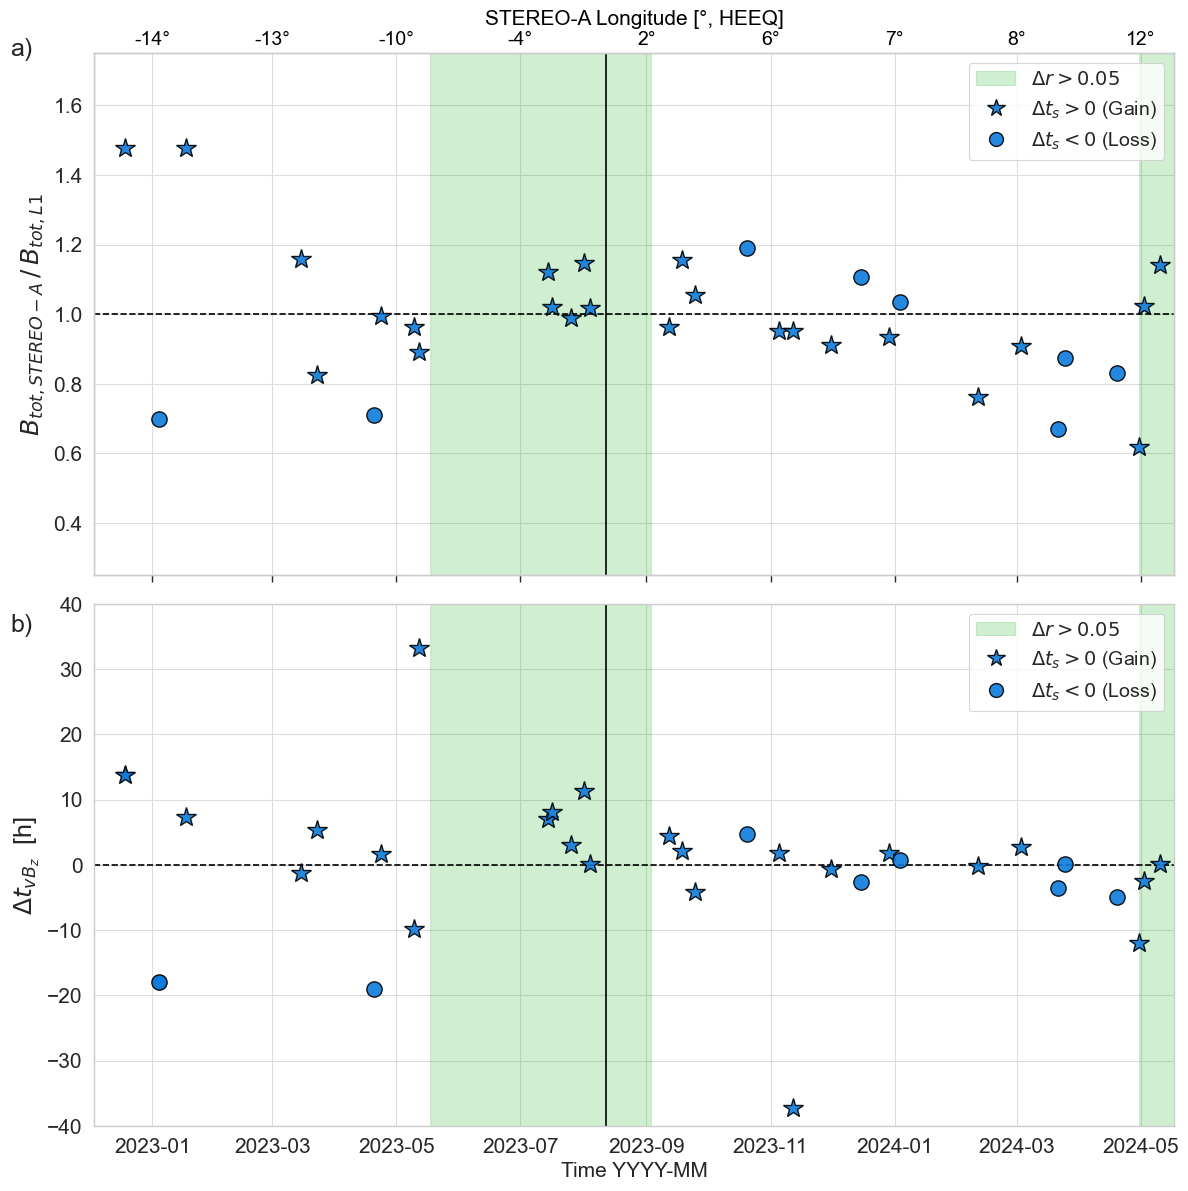

In [63]:
lw = 0.6
lw1 = 0.9
fntsize=14
days_dist = 1/2

c0 = "xkcd:black"
c1 = "xkcd:magenta"
c2 = '#FFC20A' #"xkcd:orange"
c3 = '#0C7BDC' #"xkcd:azure"
c4 = "xkcd:green"

fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(12,12), dpi=100)

ax1.fill_between(sc_input.time, -10, 100, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$')
ax1.plot([times.sta_start[0]-timedelta(days=15),times.sta_start[30]+timedelta(days=15)], [1,1], 'k--')
ax1.plot(times.sta_start[0], change_btot[0], marker='*', linestyle=' ', ms=13, color=c3, alpha=0.9, mec='black', label=r'$\Delta t_s > 0$ (Gain)')
ax1.plot(times.sta_start[1], change_btot[1], marker='o', linestyle=' ', ms=10, color=c3, alpha=0.9, mec='black', label=r'$\Delta t_s < 0$ (Loss)')
for i in range(len(diff_btot)):
    if diff_arrival_hours[i] >= 0:
        marker = '*'
        markersize = 15
    else: 
        marker = 'o'
        markersize = 11
    #if diff_btot[i]<0.: color=c2
    #else: color=c3 
    ax1.plot(times.sta_start[i], ratio_btot[i], marker=marker, ms=markersize, linestyle=' ', mec='black', color=c3, alpha=0.9)

ax1.set_ylim(0.25,1.75)
ax1.set_ylabel(r'$B_{tot, STEREO-A}\, / \, B_{tot, L1}$', fontsize=18)
ax1.plot([datetime(2023,8,12),datetime(2023,8,12)], [-10,100], 'k-')
ax1.set_xlim(times.sta_start[0]-timedelta(days=15),times.sta_start[30]+timedelta(days=15))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend(fontsize=14, loc='upper right')
ax3 = ax1.twiny()
ticks = ax1.get_xticks()
ax3.set_xticks(mdates.num2date(ticks))
ax3.grid(False)
t_float=mdates.date2num(sc_input.time)
lon_interp = np.interp(ticks, t_float, sc_input_heeq.lon)
ax3.set_xticklabels([f"{L:.0f}°" for L in lon_interp], color=c0, fontsize=14)
ax3.set_xlabel('STEREO-A Longitude [°, HEEQ]', color=c0,fontsize=15)  # we already handled the x-label with ax1
ax3.tick_params(axis='x', length=0)
ax3.set_xlim(ax1.get_xlim())



ax2.fill_between(sc_input.time, -45, 45, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$') 
ax2.plot([times.sta_start[0]-timedelta(days=15),times.sta_start[30]+timedelta(days=15)], [0,0], 'k--')
ax2.plot(times.sta_start[0], diff_time_max_bv[0], marker='*', ls='', color=c3, ms=13, alpha=0.9, mec='black', label=r'$\Delta t_s > 0$ (Gain)')
ax2.plot(times.sta_start[1], diff_time_max_bv[1], marker='o', ls='', color=c3, ms=10, alpha=0.9, mec='black', label=r'$\Delta t_s < 0$ (Loss)')
for i in range(len(times.sta_start)):
    if diff_arrival_hours[i] >= 0: 
        marker = '*'
        markersize = 15
    else: 
        marker = 'o'
        markersize = 11
#    if diff_time_max_bv[i] >= 0: color=c3
#    else: color=c2
    ax2.plot(times.sta_start[i], diff_time_max_bv[i], marker=marker, ms=markersize, mec='black', color=c3, alpha=0.9)
                 
ax2.plot([datetime(2023,8,12),datetime(2023,8,12)], [-45,45], 'k-')
ax2.set_xlim(times.sta_start[0]-timedelta(days=15),times.sta_start[30]+timedelta(days=15))
ax2.set_ylim(-40,40)

ax2.set_xlabel('Time YYYY-MM', fontsize=15)
ax2.set_ylabel(r'$\Delta t_{vB_z}$  [h]', fontsize=18)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
ax2.legend(fontsize=14)
plt.figtext(0.01,0.95, 'a)', fontsize=18)
plt.figtext(0.01,0.47, 'b)', fontsize=18)

plt.tight_layout()
plt.savefig('intrinsic_variations.pdf')
                

### Statistics on speed and density

In [37]:
diff_vel = np.round(np.array(vel_sta_list) - np.array(vel_l1_list),1)
print(len(diff_vel[diff_vel<0.]))
change_vel = np.round((np.abs(diff_vel)/np.array(vel_sta_list))*100,1)
print(diff_vel, change_vel)
print(' ')
print('mean change in speed [%]: ', round(np.mean(change_vel),1))

#plt.figure(figsize=(15,8))
#plt.plot(np.arange(len(vel_sta_list)), change_vel, marker='o', linestyle=' ', color=c3)

23
[  -8.1  -19.8  -15.7   -6.1   57.1  -51.    33.5   -9.3  -18.6  -21.8
   31.7  -15.1   -0.4  -33.6   -0.5    8.   -10.6   -4.7   -2.1    5.
  -17.1  -29.1   -6.7  -14.5  -23.6    4.   -36.  -106.     3.8   34.3
   -9.9   47.6] [ 2.3  5.3  3.7  1.2 10.9 13.5  5.8  1.7  3.9  5.5  6.   3.3  0.1  9.3
  0.1  1.4  2.4  1.4  0.4  1.1  3.7  6.6  1.8  3.2  5.2  1.1 11.2 15.9
  0.9  8.4  2.3  6.2]
 
mean change in speed [%]:  4.6


In [38]:
diff_den = np.array(den_sta_list) - np.array(den_l1_list)
print(len(diff_den[diff_den<0.]))
change_den = (np.abs(diff_den)/np.array(den_sta_list))*100
print(diff_den, change_den)
print(' ')
print('mean change in speed [%]: ', round(np.mean(change_den[change_den<200.]),1))
print(len(change_den))
#plt.figure(figsize=(15,8))
#plt.plot(np.arange(len(den_sta_list)), change_den, marker='o', linestyle=' ', color=c3)

14
[17.56152569  3.66602596 -7.34854535 -3.35296327 -3.9107026  -0.72088055
 -4.29563164 -1.90908259  0.77579454 -2.14602047 -0.75854314  1.06321118
  4.76549824  1.94943473  0.75176311  1.94195842  0.60372087  3.12599685
 -7.48928697 -0.32401583  1.69237096 -1.51235565  1.88412621 -4.20734605
 -6.85925976  2.18997145  5.31562651 -0.95329535  1.14065799  0.87673099
  5.8323605   0.99664611] [ 67.54614401  28.24380285 205.04724826  24.56245069  34.76872097
  14.22554674  78.10511906  32.57643205   8.33891113  66.32205401
  21.94114288  17.37128081  30.2886256   25.26810201   6.5556463
  29.77141663   4.4711127   30.41209435  55.38793271   3.48419487
  16.38439672  10.42721873  17.07009961  73.64610437 240.2880166
  22.45271187  37.84869603  19.73023885   8.48699949  11.25784138
  45.45253302   6.07123098]
 
mean change in speed [%]:  28.3
32


### Plot all 32 CME events

In [54]:
lw = 0.6
lw1 = 1.5
fntsize=18
days_dist = 1

#time_dst_new = mdates.num2date(sc_0_test_dst_min['time'])


for i in range(len(times.sta_start)):
#for i in range(25,30):    
    print('Processing: ', str(i+1))
    
    t_start = sc_input.time[sc_input.time == times.sta_start[i]]-timedelta(days=2)
    t_end = sc_input.time[sc_input.time == times.sta_end[i]]+timedelta(days=2)
    
    t_start_l1 = l1_input.time[l1_input.time == times.l1_start[i]]-timedelta(days=2)
    t_end_l1 = l1_input.time[l1_input.time == times.l1_end[i]]+timedelta(days=2)
    
    #cut data for faster use
    if (i+1)==26:
        sc_cut = sc_science[(sc_science.time>=t_start) & (sc_science.time<=t_end)]
    else:
        sc_cut = sc_input[(sc_input.time>=t_start) & (sc_input.time<=t_end)]
    #sc_cut_symh = data1[(data1['time']>=t_start) & (data1['time']<=t_end)]
    #mask_date = (data1['time']>=t_start) & (data1['time']<=t_end)
    #time_shifted_back_cut = time_sc_shifted_back[mask_date]
    omni_cut = omni_input[(omni_input.time>=t_start) & (omni_input.time<=t_end)]
    
    #sc_cut_event = sc_input[(sc_input.time>=times.sta_start[i]) & (sc_input.time<=times.sta_end[i])]
    l1_cut = l1_input[(l1_input.time>=t_start) & (l1_input.time<=t_end)]
    #l1_cut_event = l1_input[(l1_input.time>=times.l1_start[i]) & (l1_input.time<=times.l1_end[i])]
    
    #sc_min_bz_time = sc_cut_event.time[sc_cut_event.bz==np.nanmin(sc_cut_event.bz)]
    #l1_min_bz_time = l1_cut_event.time[l1_cut_event.bz==np.nanmin(l1_cut_event.bz)]
    #sc_max_bv_time = sc_cut_event.time[sc_cut_event.bz*sc_cut_event.vt==np.nanmin(sc_cut_event.bz*sc_cut_event.vt)]
    #l1_max_bv_time = l1_cut_event.time[l1_cut_event.bz*l1_cut_event.vt==np.nanmin(l1_cut_event.bz*l1_cut_event.vt)]
    
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, sharex=True, figsize=(12,16), dpi=100)
    
    
    #ax1.plot(sc_cut.time, sc_cut.bt, color=c0, lw=lw1, alpha=0.0, label='STEREO-A')
    ax1.plot(sc_cut.time, sc_cut.bt, color=c0, label=r'$B_{tot}$', lw=lw1)
    ax1.plot(sc_cut.time, sc_cut.bx, color=c1, label=r'$B_{x}$', lw=lw1)
    ax1.plot(sc_cut.time, sc_cut.by, color=c2, label=r'$B_{y}$', lw=lw1)
    ax1.plot(sc_cut.time, sc_cut.bz, color=c3, label=r'$B_{z}$', lw=lw1)
    #ax1.plot([sc_min_bz_time,sc_min_bz_time], [-100,100], linestyle='--', color=c3, lw=lw1)
    #ax1.plot([sc_max_bv_time,sc_max_bv_time], [-100,100], linestyle='--', color=c1, lw=lw1)
    ax1.plot([times.sta_start[i],times.sta_start[i]], [-100,100], 'k-', lw=lw1, alpha=0.4)
    ax1.plot([times.sta_end[i],times.sta_end[i]], [-100,100], 'k-', lw=lw1, alpha=0.4)
    ax1.set_ylim(np.nanmin(sc_cut.bz)-20, np.nanmax(sc_cut.bt)+10)
    ax1.legend(ncol=4, loc='lower left', fontsize=fntsize-2)
    ax1.tick_params(axis='y', labelsize=15)
    ax1.set_ylabel('B [nT] GSM', fontsize=fntsize+2)
    #ax1.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y %b %d') )
    #ax1.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
    
    #ax2.plot(l1_cut.time, l1_cut.bt, color=c0, lw=lw1, alpha=0.0, label='L1')
    ax2.plot(l1_cut.time, l1_cut.bt, color=c0, label=r'$B_{tot}$', lw=lw1)
    ax2.plot(l1_cut.time, l1_cut.bx, color=c1, label=r'$B_{x}$', lw=lw1)
    ax2.plot(l1_cut.time, l1_cut.by, color=c2, label=r'$B_{y}$', lw=lw1)
    ax2.plot(l1_cut.time, l1_cut.bz, color=c3, label=r'$B_{z}$', lw=lw1)
    #ax2.plot([l1_min_bz_time,l1_min_bz_time], [-100,100], linestyle='--', color=c3, lw=lw1)
    #ax2.plot([l1_max_bv_time,l1_max_bv_time], [-100,100], linestyle='--', color=c1, lw=lw1)
    ax2.plot([times.l1_start[i],times.l1_start[i]], [-100,100], 'k-', lw=lw1, alpha=0.4)
    ax2.plot([times.l1_end[i],times.l1_end[i]], [-100,100], 'k-', lw=lw1, alpha=0.4)
    #ax2.set_xlim(t_start,t_end)
    ax2.set_ylim(np.nanmin(l1_cut.bz)-20, np.nanmax(l1_cut.bt)+10)
    ax2.legend(ncol=4, loc='lower left', fontsize=fntsize-2)
    ax2.set_ylabel('B [nT] GSM', fontsize=fntsize+2)
    #ax2.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y %b %d') )
    #ax2.tick_params(axis='x', labelsize=13)
    ax2.tick_params(axis='y', labelsize=15)
    #ax1.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
    
    ax3.plot(l1_cut.time, l1_cut.vt, color=c0, alpha=0.6, lw=lw1, label='speed L1')
    ax3.plot(sc_cut.time, sc_cut.vt, color=c3, alpha=0.6, lw=lw1, label='speed STEREO-A')
    #ax3.plot([times.l1_start[i],times.l1_start[i]], [-10,2000], 'k-', lw=lw1)
    #ax3.plot([times.l1_end[i],times.l1_end[i]], [-10,2000], 'k-', lw=lw1)
    #ax3.plot([times.sta_start[i],times.sta_start[i]], [-10,2000], linestyle='-', color=c3, lw=lw1)
    #ax3.plot([times.sta_end[i],times.sta_end[i]], [-10,2000], linestyle='-', color=c3, lw=lw1)
    
    if np.nanmin(l1_cut.vt)<np.nanmin(sc_cut.vt):
        vlim_low = np.nanmin(l1_cut.vt)-30
    else: vlim_low = np.nanmin(sc_cut.vt)-30
    
    if np.nanmax(l1_cut.vt)>np.nanmax(sc_cut.vt):
        vlim_up = np.nanmax(l1_cut.vt)+30
    else: vlim_up = np.nanmax(sc_cut.vt)+30
    
    ax3.set_ylim(vlim_low, vlim_up)
    ax3.legend(loc='upper left', ncol=2, fontsize=fntsize-2)
    ax3.tick_params(axis='y', labelsize=15)
    ax3.set_ylabel('speed [km/s]', fontsize=fntsize+2)
    #ax3.set_xlim(t_start,t_end)
    
    ax4.plot(l1_cut.time, l1_cut.np, color=c0, alpha=0.6, lw=lw1, label='density L1')
    ax4.plot(sc_cut.time, sc_cut.np, color=c3, alpha=0.6, lw=lw1, label='density STEREO-A')
    #ax4.plot([times.l1_start[i],times.l1_start[i]], [-100,100], 'k-', lw=lw1)
    #ax4.plot([times.l1_end[i],times.l1_end[i]], [-100,100], 'k-', lw=lw1)
    #ax4.plot([times.sta_start[i],times.sta_start[i]], [-100,100], linestyle='-', color=c3, lw=lw1)
    #ax4.plot([times.sta_end[i],times.sta_end[i]], [-100,100], linestyle='-', color=c3, lw=lw1)
    
    if np.nanmin(l1_cut.np)<np.nanmin(sc_cut.np):
        nlim_low = np.nanmin(l1_cut.np)-5
    else: nlim_low = np.nanmin(sc_cut.np)-5
    
    if np.nanmax(l1_cut.np)>np.nanmax(sc_cut.np):
        nlim_up = np.nanmax(l1_cut.np)+5
    else: nlim_up = np.nanmax(sc_cut.np)+5
    
    ax4.set_ylim(nlim_low, nlim_up)
    ax4.legend(loc='upper left', ncol=2, fontsize=fntsize-2)
    ax4.tick_params(axis='y', labelsize=15)
    ax4.set_ylabel(r'density [cm$^{-3}$]', fontsize=fntsize+2)
    ax4.set_xlim(t_start,t_end)
    ax4.set_xlabel('Time YYYY-MM-DD', fontsize=fntsize+2)
    ax4.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y-%m-%d') )
    ax4.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
    
    if t_start>t_start_l1:
        t_start_lim = times.l1_start[i]-timedelta(days=0.5)
    else: t_start_lim = times.sta_start[i]-timedelta(days=0.5)
    
    if t_end>t_end_l1:
        t_end_lim = times.sta_end[i]+timedelta(days=0.5)
    else: t_end_lim = times.l1_end[i]+timedelta(days=0.5)
    
    ax4.set_xlim(t_start_lim,t_end_lim)
    
    ax4.tick_params(axis='x', labelsize=15)
    
    plt.figtext(0.086,0.97, 'STEREO-A', fontsize=20)
    plt.figtext(0.086,0.73, 'L1', fontsize=20)
    plt.figtext(0.01,0.97, 'a)', fontsize=18)
    plt.figtext(0.01,0.73, 'b)', fontsize=18)
    plt.figtext(0.01,0.49, 'c)', fontsize=18)
    plt.figtext(0.01,0.25, 'd)', fontsize=18)
    
    
    fig.tight_layout()
                                                         
    plt.savefig('figures/CME_event_'+str(i+1)+'.png')
    plt.close()
    #fig.rcParams.update({'axes.titlesize': 'xx-large'})

Processing:  1
Processing:  2
Processing:  3
Processing:  4
Processing:  5
Processing:  6
Processing:  7
Processing:  8
Processing:  9
Processing:  10
Processing:  11
Processing:  12
Processing:  13
Processing:  14
Processing:  15
Processing:  16
Processing:  17
Processing:  18
Processing:  19
Processing:  20
Processing:  21
Processing:  22
Processing:  23
Processing:  24
Processing:  25
Processing:  26
Processing:  27
Processing:  28
Processing:  29
Processing:  30
Processing:  31
Processing:  32
